In [7]:
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt
from scipy.spatial import Delaunay

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})

def alpha_shape(points, alpha, only_outer=True):
    """
    Compute the alpha shape (concave hull) of a set of points.
    :param points: np.array of shape (n,2) points.
    :param alpha: alpha value.
    :param only_outer: boolean value to specify if we keep only the outer border
    or also inner edges.
    :return: set of (i,j) pairs representing edges of the alpha-shape. (i,j) are
    the indices in the points array.
    """
    assert points.shape[0] > 3, "Need at least four points"
    def add_edge(edges, i, j):
        """
        Add an edge between the i-th and j-th points,
        if not in the list already
        """
        if (i, j) in edges or (j, i) in edges:
            # already added
            assert (j, i) in edges, "Can't go twice over same directed edge right?"
            if only_outer:
                # if both neighboring triangles are in shape, it's not a boundary edge
                edges.remove((j, i))
            return
        edges.add((i, j))
    tri = Delaunay(points)
    edges = set()
    # Loop over triangles:
    # ia, ib, ic = indices of corner points of the triangle
    for ia, ib, ic in tri.vertices:
        pa = points[ia]
        pb = points[ib]
        pc = points[ic]
        # Computing radius of triangle circumcircle
        # www.mathalino.com/reviewer/derivation-of-formulas/derivation-of-formula-for-radius-of-circumcircle
        a = np.sqrt((pa[0] - pb[0]) ** 2 + (pa[1] - pb[1]) ** 2)
        b = np.sqrt((pb[0] - pc[0]) ** 2 + (pb[1] - pc[1]) ** 2)
        c = np.sqrt((pc[0] - pa[0]) ** 2 + (pc[1] - pa[1]) ** 2)
        s = (a + b + c) / 2.0
        area = np.sqrt(s * (s - a) * (s - b) * (s - c))
        circum_r = a * b * c / (4.0 * area)
        if circum_r < alpha:
            add_edge(edges, ia, ib)
            add_edge(edges, ib, ic)
            add_edge(edges, ic, ia)
    return edges
import seaborn as sns
from matplotlib import pyplot as plt
def dotplot(data, x, y, color, size, sizes=(0,75), colors=(-0.5,0.5), dpi=300):
    #normalize = mcolors.TwoSlopeNorm(vcenter=0, vmin=colors[0], vmax=colors[1])
    # colormap = cm.PiYG
    if colors:
        data[color]=data[color].clip(colors[0], colors[1])





    data[x]=data[x].astype("category")
    data[y]=data[y].astype("category")

    x_lab=data[x].cat.categories
    y_lab=data[y].cat.categories

    f=sns.clustermap(data.pivot(index=y, columns=x, values=color),figsize=(0.1,0.1), cmap='PiYG')

    x_lab=x_lab[f.dendrogram_col.reordered_ind]
    y_lab=y_lab[f.dendrogram_row.reordered_ind]


    data[x]=data[x].cat.reorder_categories(x_lab)
    data[y]=data[y].cat.reorder_categories(y_lab)
    data=data.sort_values([x, y])


    plt.figure(figsize=(0.2*len(x_lab),0.2*len(y_lab)), dpi=dpi)

    ax =sns.scatterplot(data=data,
                        y=y,
                        x=x,
                        hue=color,
                        palette="PiYG",
                        size=size,
                        sizes=sizes)

    ax.set_xlim(-0.5, -0.5+len(x_lab))
    ax.set_ylim(-0.5, -0.5+len(y_lab))

    ax.set_xticklabels(x_lab,rotation = 90)
    plt.legend(bbox_to_anchor=(1.05,1),
               loc='upper left',
               borderaxespad=0)
    return ax


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


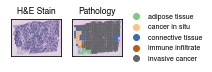

<Figure size 432x288 with 0 Axes>

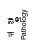

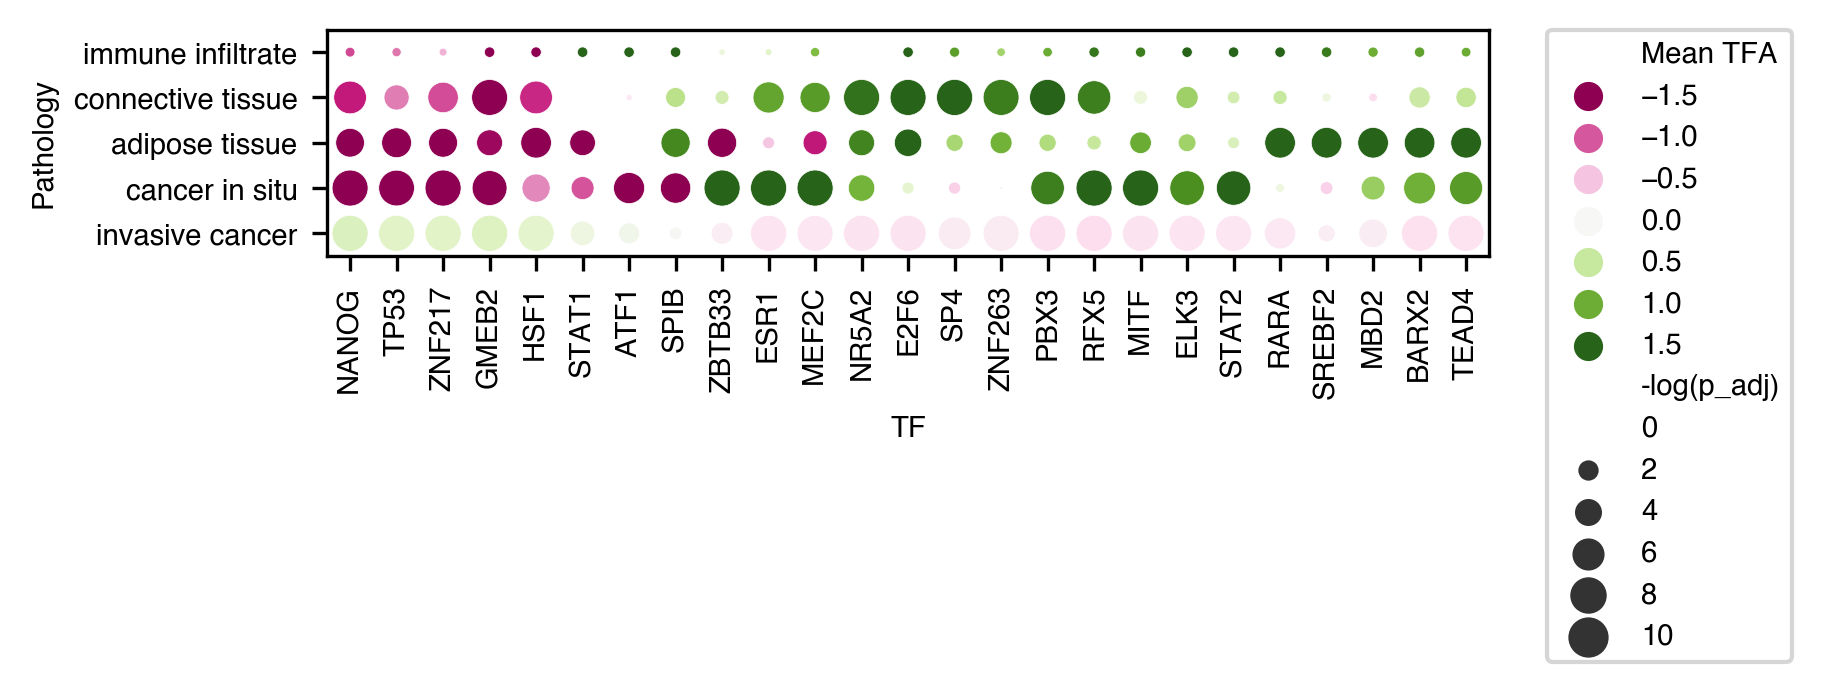

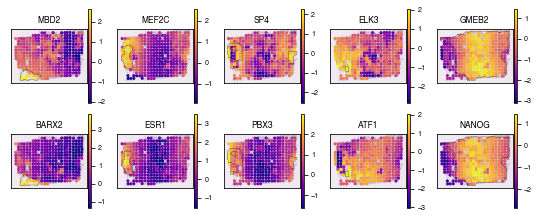

In [9]:
sample="A1"

adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !="undetermined"]
adata=adata[adata.obs['pathology'] !=np.nan]


f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean TFA', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean TFA", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),2))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-100,100], points +[-100,-100], points +[100,100], points +[100,-100]))
    edges=alpha_shape(points, alpha=250, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


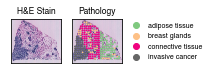

<Figure size 432x288 with 0 Axes>

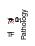

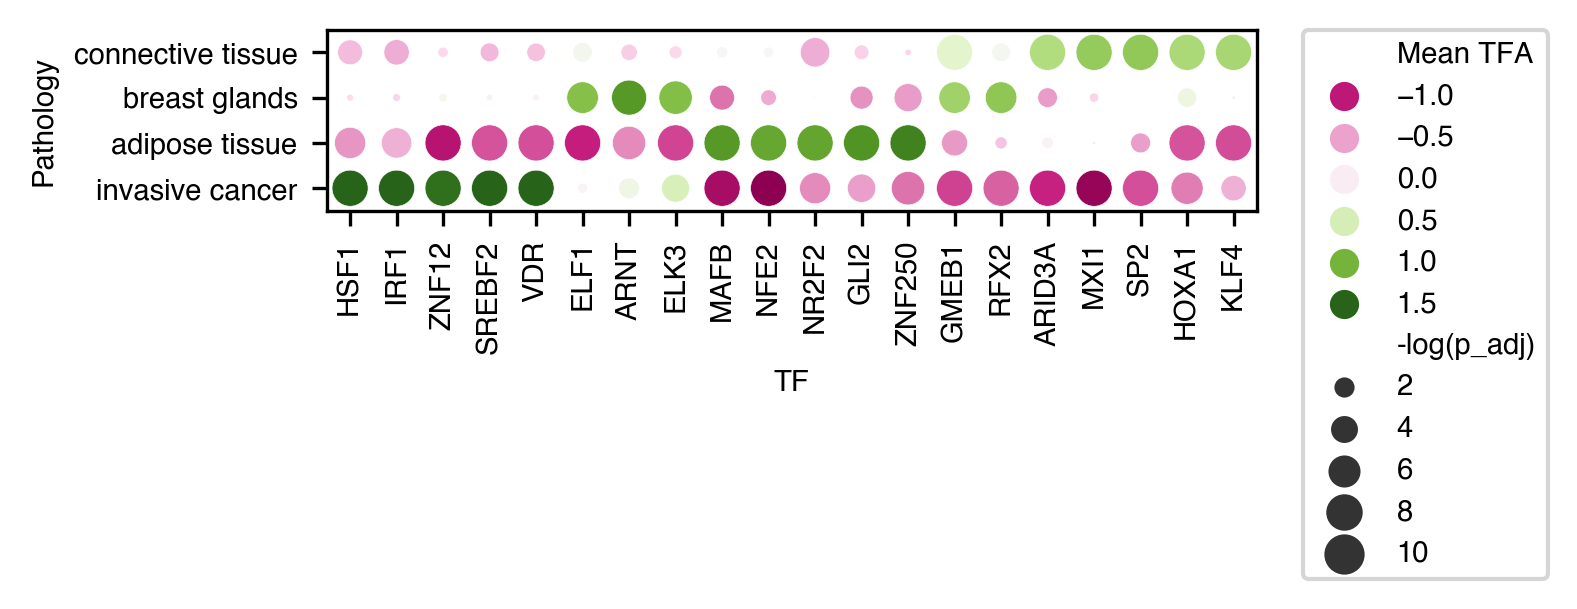

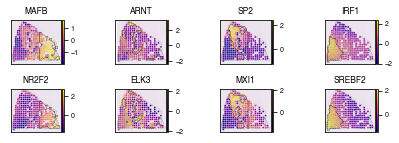

In [10]:
sample="B1"

adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !="undetermined"]
adata=adata[adata.obs['pathology'] !=np.nan]


f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean TFA', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean TFA", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),2.5))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-100,100], points +[-100,-100], points +[100,100], points +[100,-100]))
    edges=alpha_shape(points, alpha=250, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


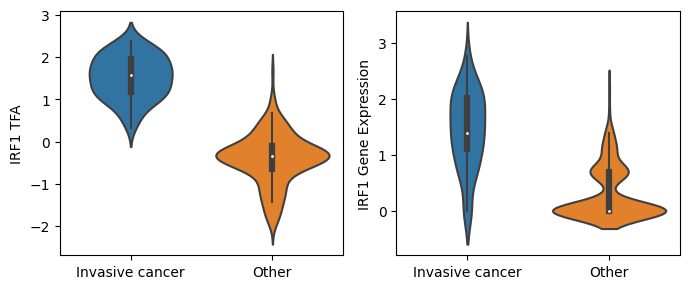

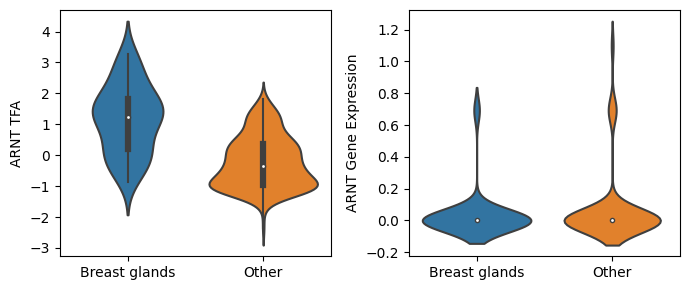

In [6]:
adata_raw=sc.read_h5ad("data/Andersson2021/B1.h5ad")
adata.layers['gex']=sc.get.obs_df(adata_raw, adata.var_names.to_list()).loc[adata.obs_names]

fig, axs=plt.subplots(1,2,figsize=(7,3))
x=(adata.obs['pathology']=="invasive cancer").map({True: "Invasive cancer", False: "Other"})
sns.violinplot(y=adata.to_df()["IRF1"], x=x, ax=axs[0], order=["Invasive cancer", "Other"])
sns.violinplot(y=np.log(adata.to_df("gex")["IRF1"]+1), x=x, ax=axs[1], order=["Invasive cancer", "Other"])
axs[0].set_ylabel("IRF1 TFA")
axs[1].set_ylabel("IRF1 Gene Expression")
axs[0].set_xlabel("")
axs[1].set_xlabel("")
plt.tight_layout()


fig, axs=plt.subplots(1,2,figsize=(7,3))
x=(adata.obs['pathology']=="breast glands").map({True: "Breast glands", False: "Other"})
sns.violinplot(y=adata.to_df()["ARNT"], x=x, ax=axs[0], order=["Breast glands", "Other"])
sns.violinplot(y=np.log(adata.to_df("gex")["ARNT"]+1), x=x, ax=axs[1], order=["Breast glands", "Other"])
axs[0].set_ylabel("ARNT TFA")
axs[1].set_ylabel("ARNT Gene Expression")
axs[0].set_xlabel("")
axs[1].set_xlabel("")
plt.tight_layout()

Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


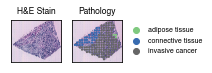

<Figure size 432x288 with 0 Axes>

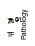

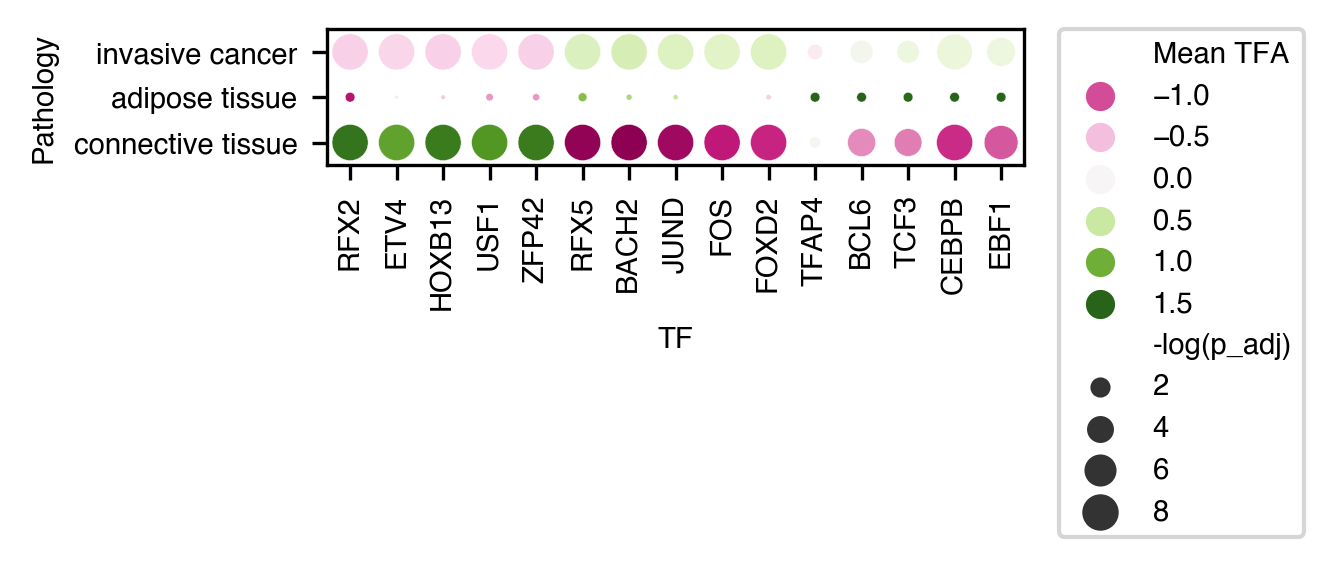

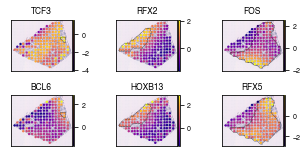

In [11]:
sample="C1"

adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !="undetermined"]
adata=adata[adata.obs['pathology'] !=np.nan]


f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean TFA', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean TFA", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),2.2))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-100,100], points +[-100,-100], points +[100,100], points +[100,-100]))
    edges=alpha_shape(points, alpha=250, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


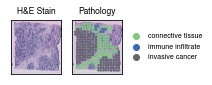

<Figure size 432x288 with 0 Axes>

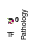

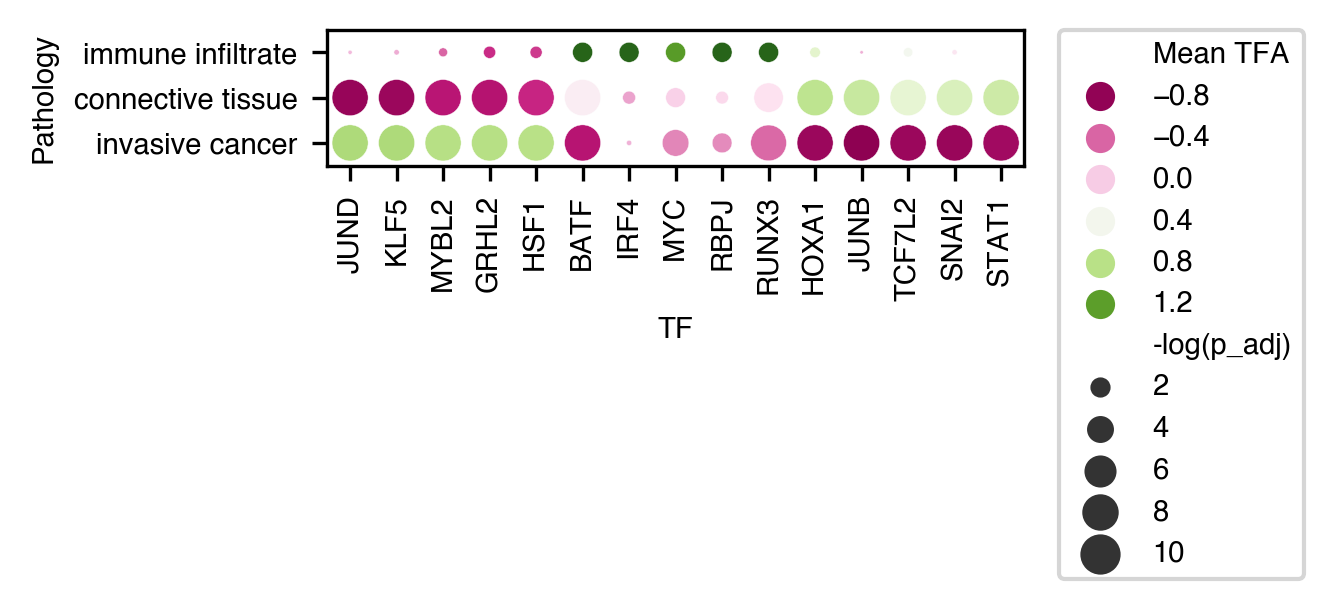

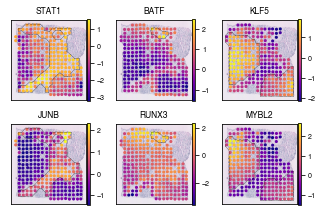

In [12]:
sample="D1"

adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !="undetermined"]
adata=adata[adata.obs['pathology'] !=np.nan]


f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean TFA', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean TFA", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),3))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-100,100], points +[-100,-100], points +[100,100], points +[100,-100]))
    edges=alpha_shape(points, alpha=250, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


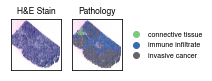

<Figure size 432x288 with 0 Axes>

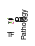

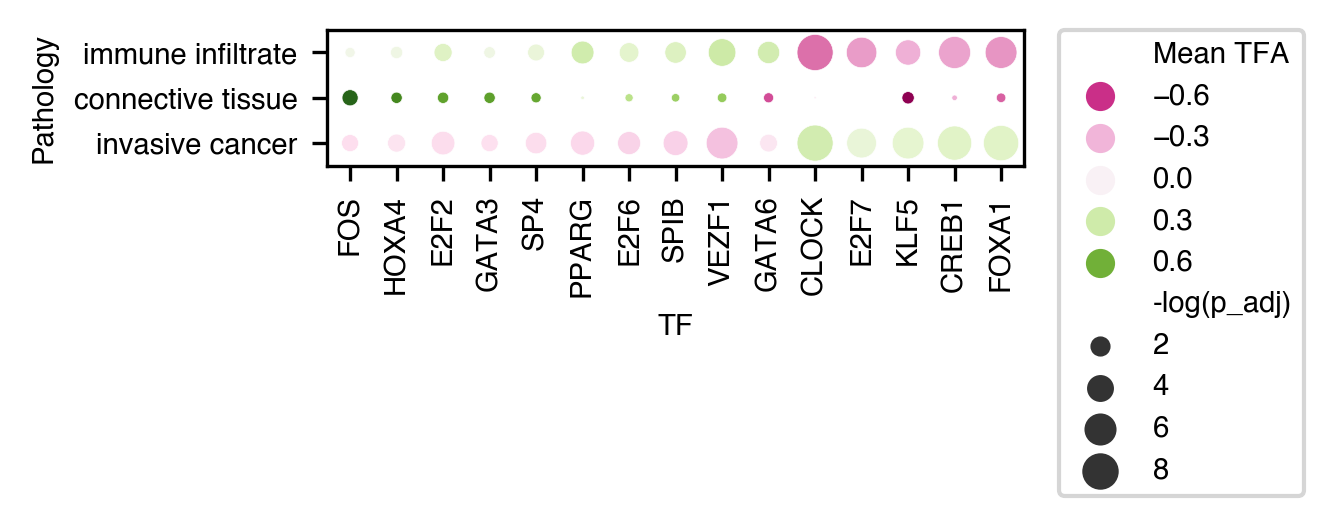

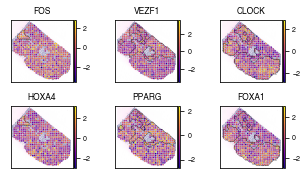

Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


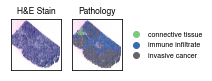

<Figure size 432x288 with 0 Axes>

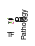

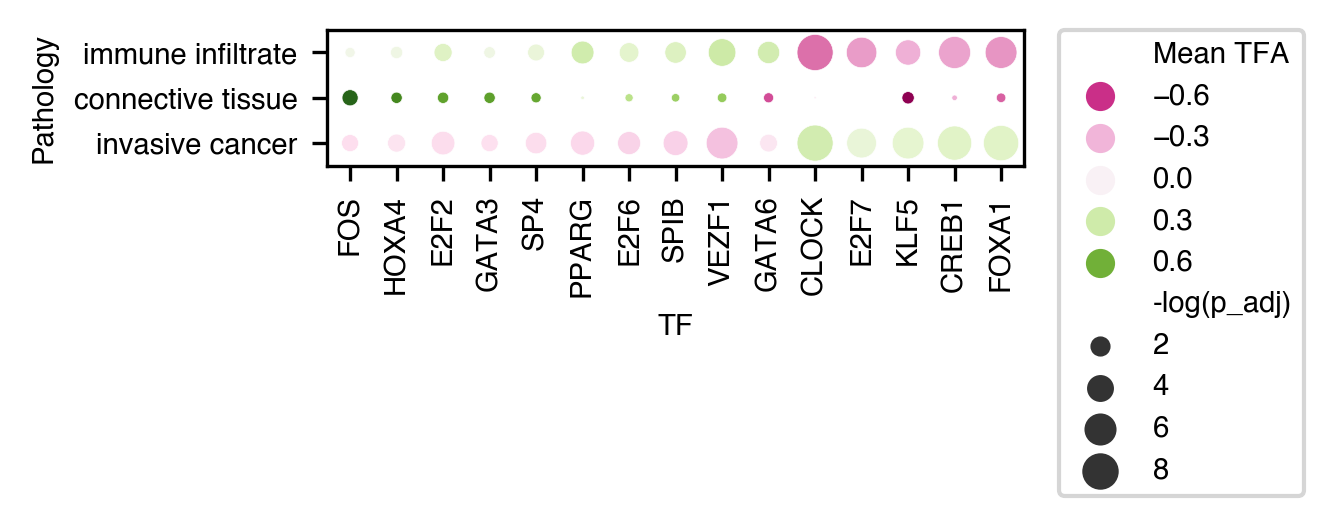

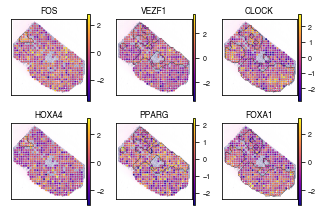

In [14]:
sample="E1"
adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !="undetermined"]
adata=adata[adata.obs['pathology'] !=np.nan]


f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean TFA', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean TFA", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),3))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-100,100], points +[-100,-100], points +[100,100], points +[100,-100]))
    edges=alpha_shape(points, alpha=250, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


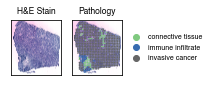

<Figure size 432x288 with 0 Axes>

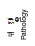

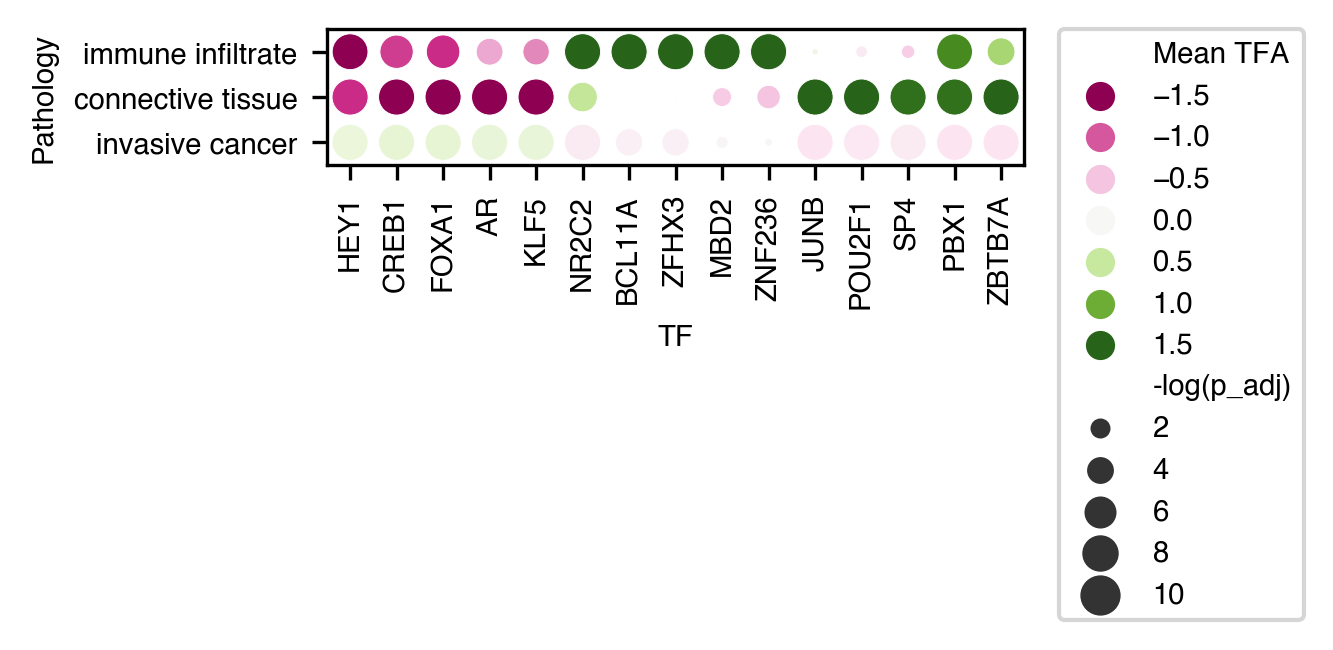

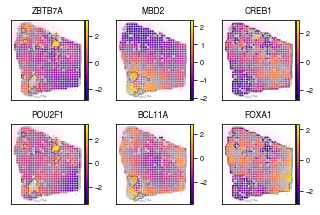

In [15]:
sample="F1"

adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !="undetermined"]
adata=adata[adata.obs['pathology'] !=np.nan]


f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean TFA', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean TFA", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),3))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-100,100], points +[-100,-100], points +[100,100], points +[100,-100]))
    edges=alpha_shape(points, alpha=250, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


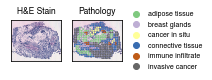

<Figure size 432x288 with 0 Axes>

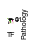

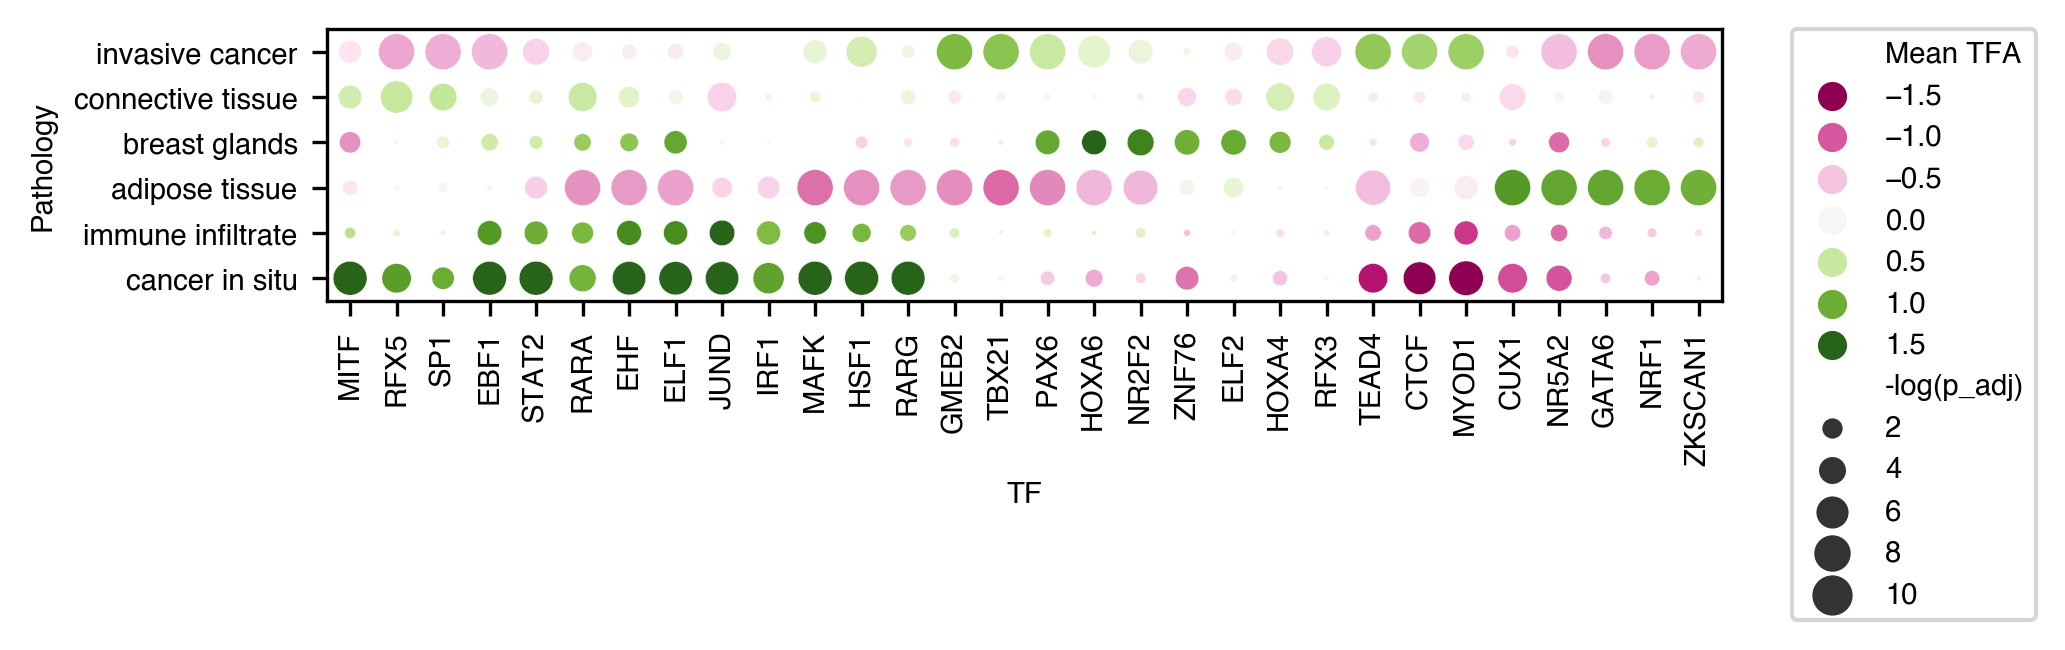

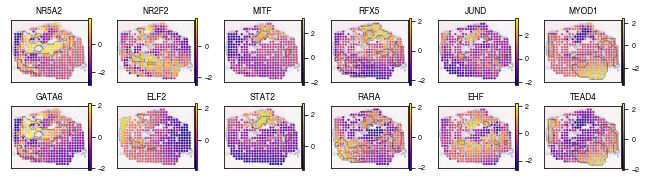

In [16]:
sample="G2"
adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !="undetermined"]
adata=adata[adata.obs['pathology'] !=np.nan]


f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean TFA', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean TFA", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),2.5))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-100,100], points +[-100,-100], points +[100,100], points +[100,-100]))
    edges=alpha_shape(points, alpha=250, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


Trying to set attribute `.uns` of view, copying.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


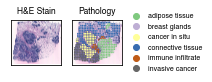

<Figure size 432x288 with 0 Axes>

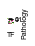

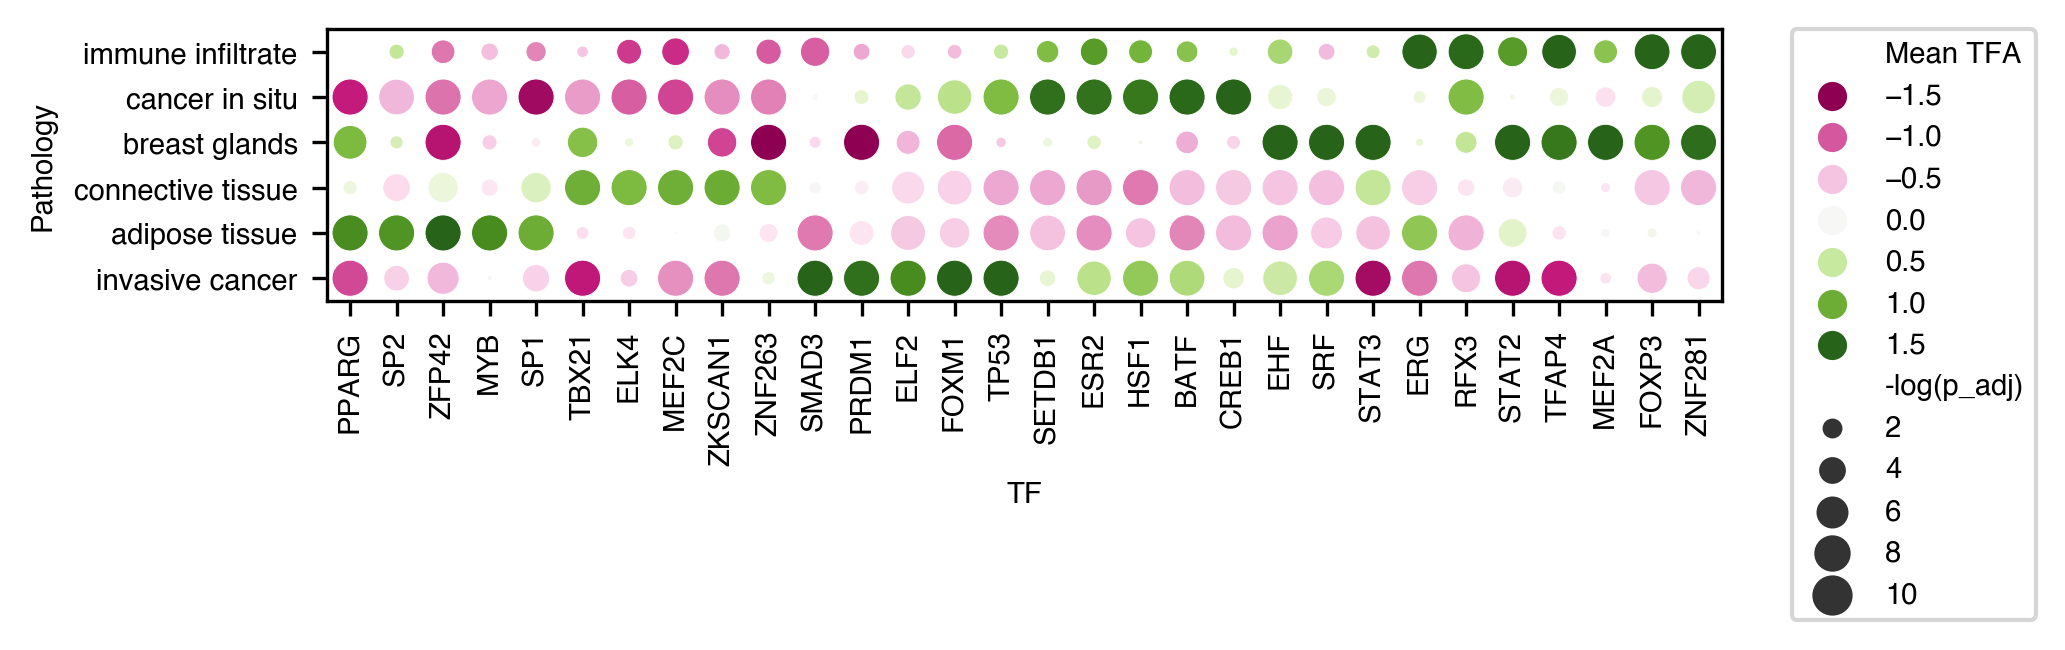

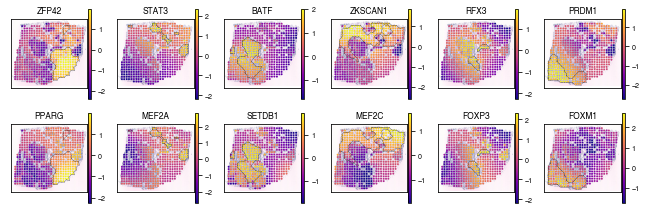

In [17]:
sample="H1"

adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !="undetermined"]
adata=adata[adata.obs['pathology'] !=np.nan]


f,axs=plt.subplots(1,2,figsize=(2,2))
sc.pl.spatial(adata, color=[None], size=2, palette='Accent', show=False, ax=axs[0], title='H&E Stain')
sc.pl.spatial(adata, color=['pathology'], size=2, palette='Accent', show=False, ax=axs[1], title='Pathology')

axs[0].set_xlabel("")
axs[0].set_ylabel("")
axs[1].set_xlabel("")
axs[1].set_ylabel("")
plt.savefig('figures/'+sample+"diff_exp_pathology.pdf", bbox_inches='tight', padding_inches=0)


sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")



plt.figure()
categories=adata.obs['pathology'].cat.categories
mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
df=[]
for i in range(len(adata.uns['rank_genes_groups']['names'])):
    for j, cat in enumerate(categories):
        tf=adata.uns['rank_genes_groups']['names'][i][j]
        pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
        mean=mean_df.loc[cat, tf]
        df.append([tf, cat, mean, -np.log10(pval+1e-10), i])
df=pd.DataFrame(df, columns=['TF', 'Pathology', 'Mean TFA', '-log(p_adj)', 'rank'])
top_tfs=[ x for sub in adata.uns['rank_genes_groups']['names'][0:5] for x in sub]
df=df.query("TF in @top_tfs")
df['TF']=df['TF'].astype("category")
df['TF']=df['TF'].cat.remove_unused_categories()
dotplot(df, x="TF", y='Pathology', color="Mean TFA", size="-log(p_adj)", colors=(-1.5,1.5))
plt.savefig('figures/'+sample+"diff_exp_dotplot.pdf", bbox_inches='tight', padding_inches=0)


f, axs = plt.subplots(2, len(categories), figsize=(1.5*len(categories),3))
for i in range(len(categories)):
    points=np.asarray(adata[adata.obs['pathology']==categories[i]].obsm['spatial']*adata.uns['spatial'][sample]['scalefactors']['tissue_hires_scalef'])
    points=np.vstack((points +[-100,100], points +[-100,-100], points +[100,100], points +[100,-100]))
    edges=alpha_shape(points, alpha=250, only_outer=True)
    for j in range(2):
        sc.pl.spatial(adata, color=adata.uns['rank_genes_groups']['names'][j][i], size=1.8, cmap='plasma', alpha_img=0.5, ax=axs[j,i], show=False)
        axs[j,i].set_xlabel("")
        axs[j,i].set_ylabel("")
        for ii, jj in edges:
            axs[j,i].plot(points[[ii, jj], 0], points[[ii, jj], 1], 'k', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/'+sample+"diff_exp_TFA.pdf", bbox_inches='tight', padding_inches=0)


# Compare Pathology accross samples


In [19]:
df=[]
for sample in ["A1", "B1", "C1", "D1", "E1", "F1", "G2", "H1"]:
    adata=sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
    adata=adata[adata.obs['pathology'] !="Artefact"]
    adata=adata[adata.obs['pathology'] !="Uncertain"]
    adata=adata[adata.obs['pathology'] !=np.nan]
    sc.tl.rank_genes_groups(adata, layer='stan_tfa', groupby='pathology', method="wilcoxon")

    categories=adata.obs['pathology'].cat.categories
    mean_df=adata.to_df().groupby(adata.obs['pathology']).mean()
    for i in range(len(adata.uns['rank_genes_groups']['names'])):
        for j, cat in enumerate(categories):
            tf=adata.uns['rank_genes_groups']['names'][i][j]
            pval=adata.uns['rank_genes_groups']['pvals_adj'][i][j]
            mean=mean_df.loc[cat, tf]
            df.append([sample, tf, cat, mean, pval, i/adata.n_vars])
df=pd.DataFrame(df, columns=['Sample','TF', 'Pathology', 'Mean', 'p_adj', 'rank'])




Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.
Trying to set attribute `.uns` of view, copying.


In [20]:
df[["Pathology", "Sample"]].value_counts().unstack()>0

Sample,A1,B1,C1,D1,E1,F1,G2,H1
Pathology,,,,,,,,
adipose tissue,True,True,True,False,False,False,True,True
breast glands,False,True,False,False,False,False,True,True
cancer in situ,True,False,False,False,False,False,True,True
connective tissue,True,True,True,True,True,True,True,True
immune infiltrate,True,False,False,True,True,True,True,True
invasive cancer,True,True,True,True,True,True,True,True
undetermined,True,True,True,True,True,True,True,True


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


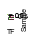

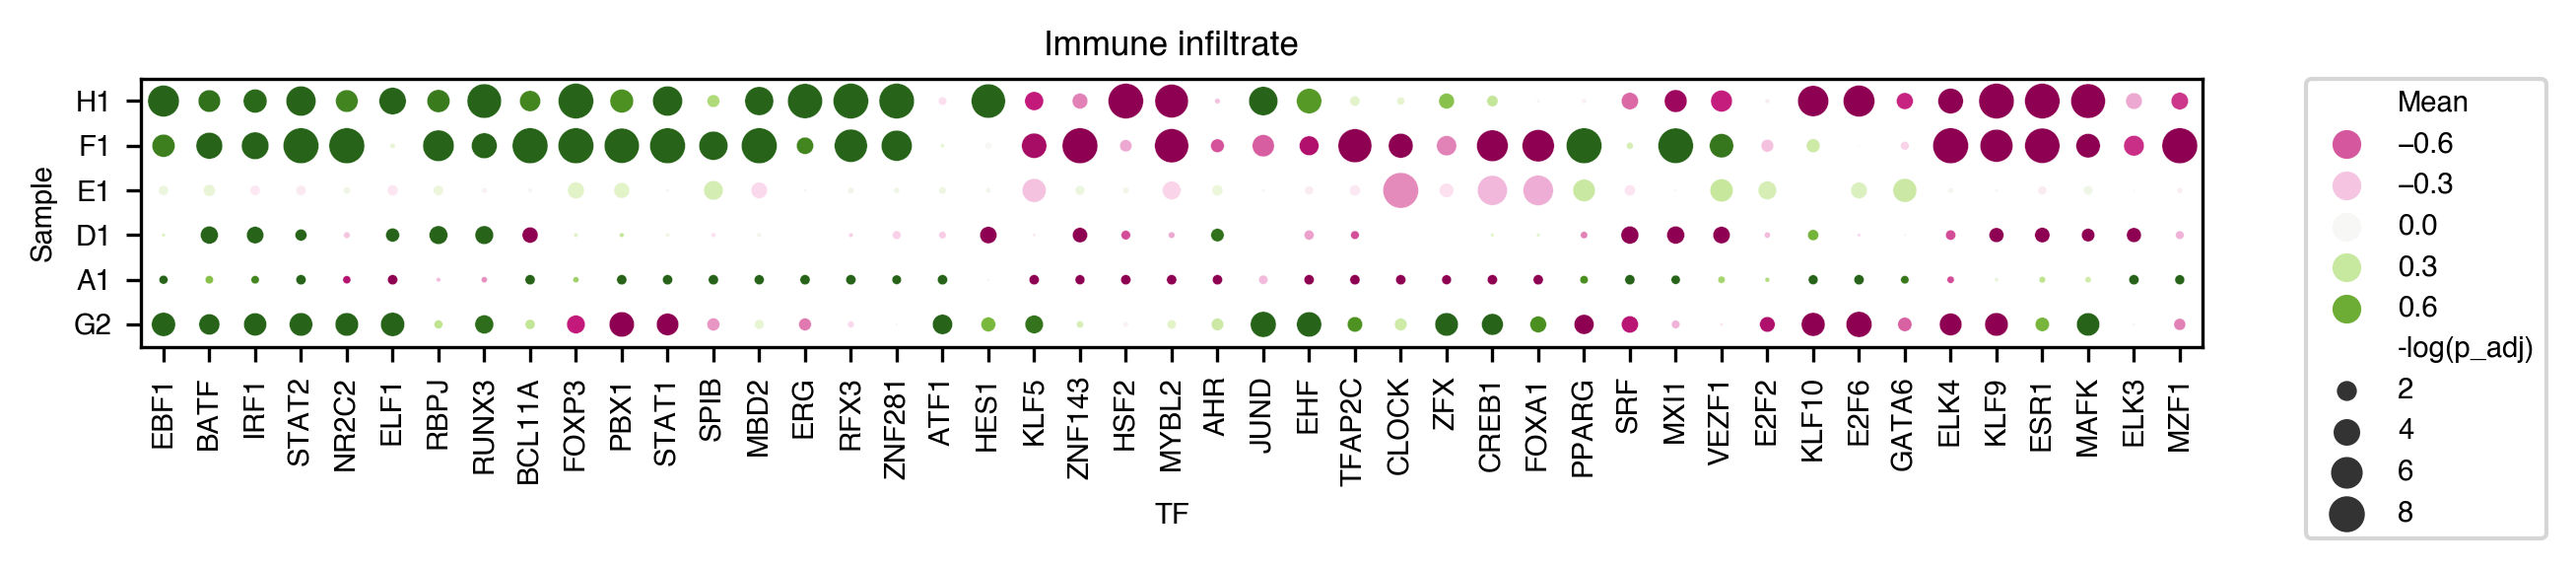

In [21]:
df['-log(p_adj)']=-np.log10(df['p_adj']+1e-10)
tfs=df.query("Pathology=='immune infiltrate' and (rank<0.02 or rank>0.98)")['TF'].unique() #get top 5% for each sample
tfs=df.query("Pathology=='immune infiltrate' and TF in @tfs").pivot(index="Sample", columns="TF", values="Mean").dropna(axis=1).columns #only keep tfs with in all samples
df_subset=df.query("Pathology=='immune infiltrate' and TF in @tfs")

df_subset['TF']=df_subset['TF'].astype("category")
df_subset['TF']=df_subset['TF'].cat.remove_unused_categories()
dotplot(df_subset, x="TF", y='Sample', color="Mean", size="-log(p_adj)", colors=(-0.9,0.9))
plt.title("Immune infiltrate")
plt.savefig('figures/Andersson_diff_exp_immune_infiltrate.pdf', bbox_inches='tight', padding_inches=0)



1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


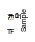

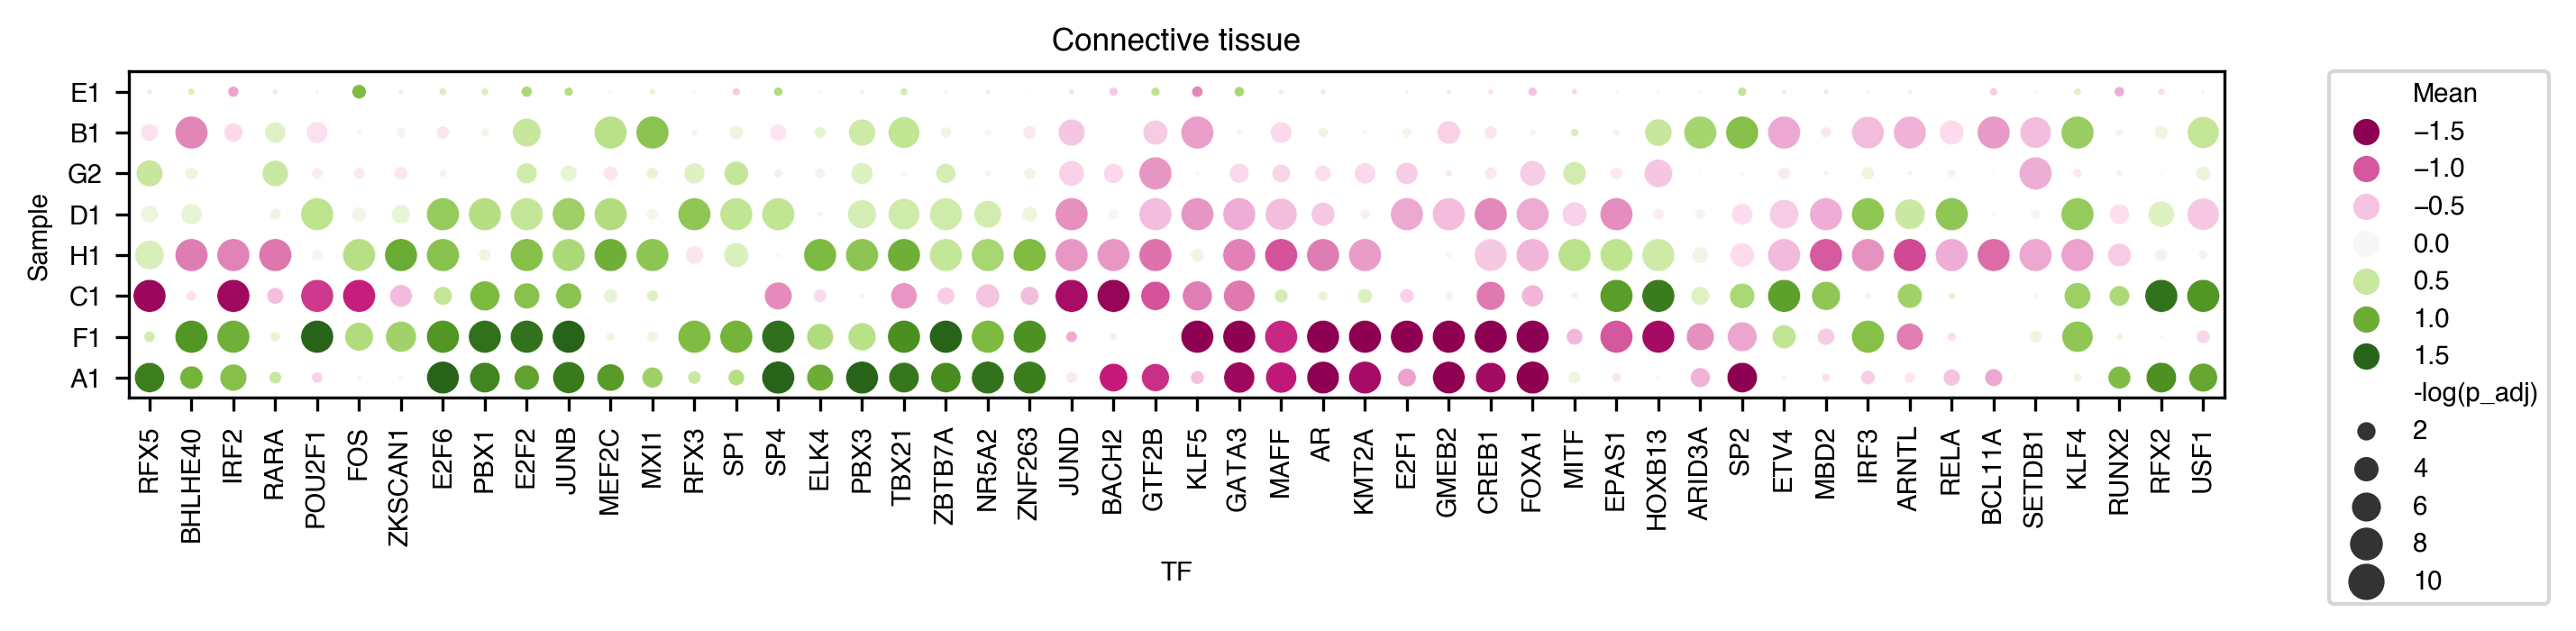

In [22]:
df['-log(p_adj)']=-np.log10(df['p_adj']+1e-10)
tfs=df.query("Pathology=='connective tissue' and (rank<0.02 or rank>0.98)")['TF'].unique() #get top 5% for each sample
tfs=df.query("Pathology=='connective tissue' and TF in @tfs").pivot(index="Sample", columns="TF", values="Mean").dropna(axis=1).columns #only keep tfs with in all samples
df_subset=df.query("Pathology=='connective tissue' and TF in @tfs")

df_subset['TF']=df_subset['TF'].astype("category")
df_subset['TF']=df_subset['TF'].cat.remove_unused_categories()
dotplot(df_subset, x="TF", y='Sample', color="Mean", size="-log(p_adj)", colors=(-1.5, 1.5))

plt.title("Connective tissue")
plt.savefig('figures/Andersson_diff_exp_connective_tissue.pdf', bbox_inches='tight', padding_inches=0)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


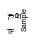

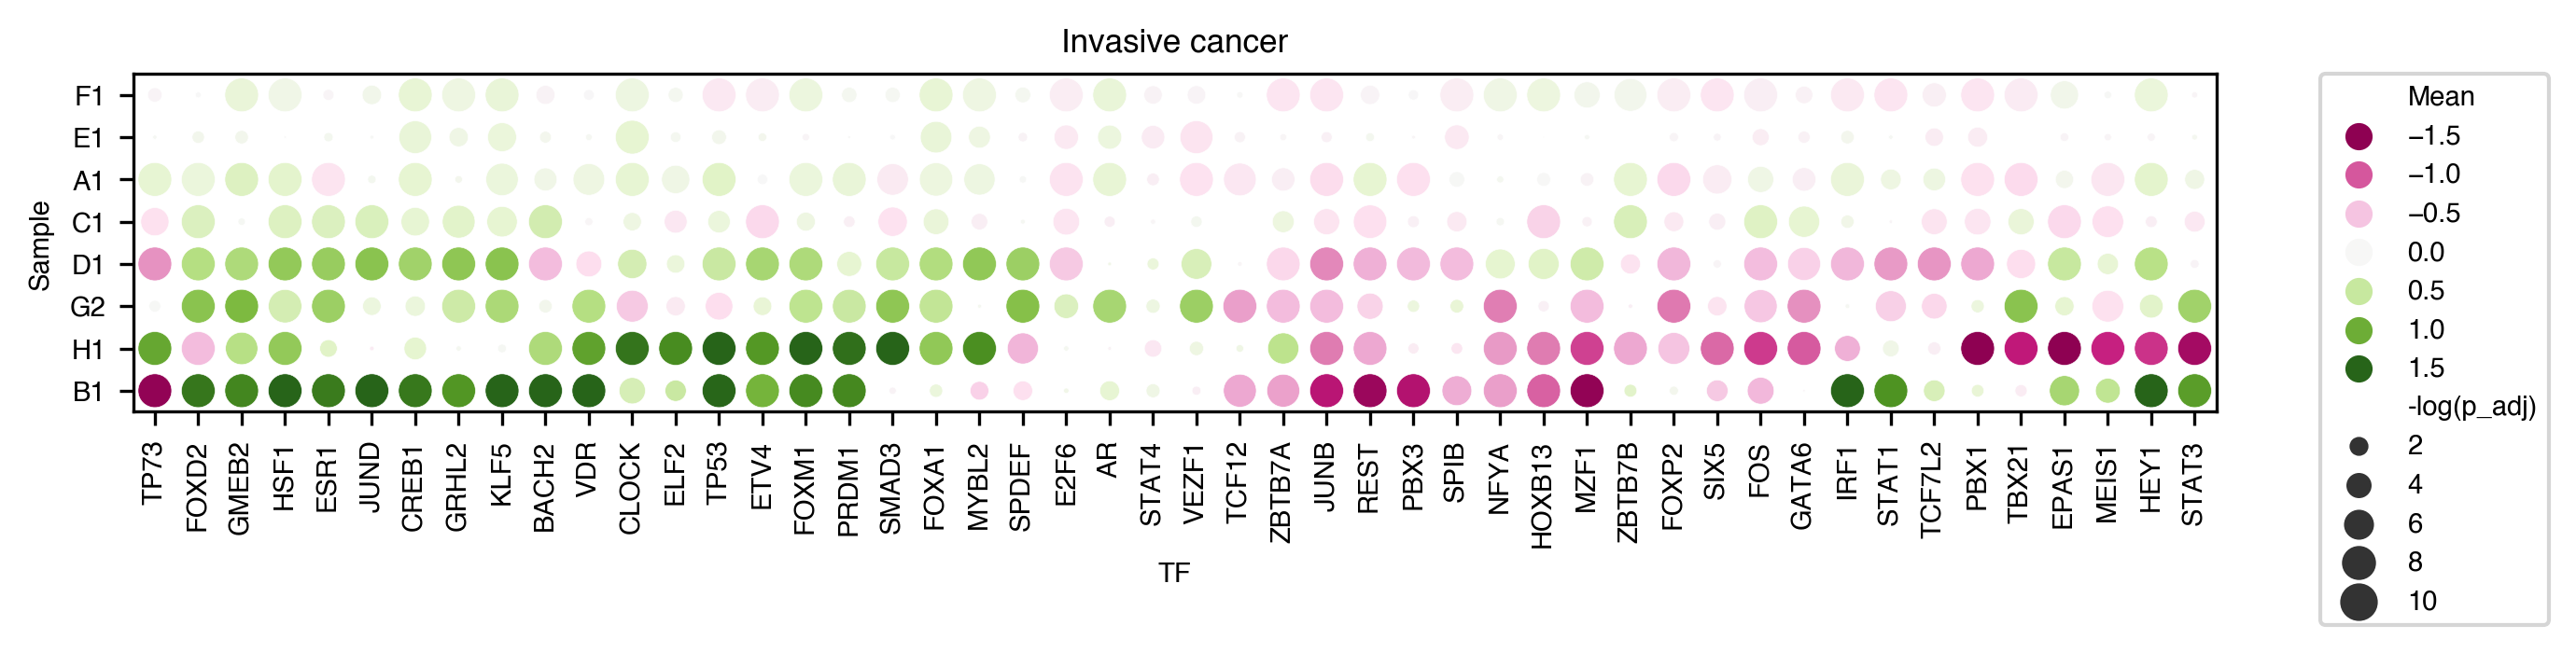

In [23]:
df['-log(p_adj)']=-np.log10(df['p_adj']+1e-10)
tfs=df.query("Pathology=='invasive cancer' and (rank<0.02 or rank>0.98)")['TF'].unique() #get top 5% for each sample
tfs=df.query("Pathology=='invasive cancer' and TF in @tfs").pivot(index="Sample", columns="TF", values="Mean").dropna(axis=1).columns #only keep tfs with in all samples
df_subset=df.query("Pathology=='invasive cancer' and TF in @tfs")

df_subset['TF']=df_subset['TF'].astype("category")
df_subset['TF']=df_subset['TF'].cat.remove_unused_categories()
dotplot(df_subset, x="TF", y='Sample', color="Mean", size="-log(p_adj)", colors=(-1.5, 1.5))

plt.title("Invasive cancer")
plt.savefig('figures/Andersson_diff_exp_invasive_cancer.pdf', bbox_inches='tight', padding_inches=0)


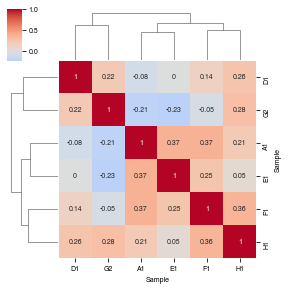

In [24]:
sns.clustermap(df.query("Pathology=='immune infiltrate'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
               cmap="coolwarm", center=0, annot=True, figsize=(4,4))

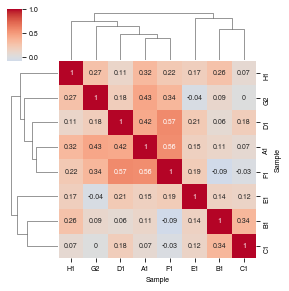

In [25]:
sns.clustermap(df.query("Pathology=='connective tissue'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
               cmap="coolwarm", center=0, annot=True, figsize=(4,4))

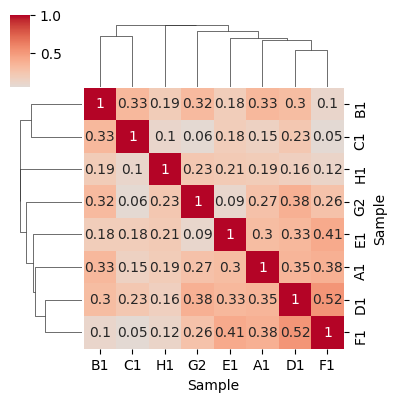

In [21]:
sns.clustermap(df.query("Pathology=='invasive cancer'").pivot(columns="Sample", index="TF", values="Mean").dropna().corr().round(2),
               cmap="coolwarm", center=0, annot=True, figsize=(4,4))